In [1]:
'''PSFMachine is an open source Python tool for creating models of instrument
 effective Point Spread Functions (ePSFs), a.k.a Pixel Response Functions (PRFs).
 These models are then used to fit a scene in a stack of astronomical images. 
 PSFMachine is able to quickly derive photometry from stacks of Kepler images 
 and separate crowded sources.
'''

'''
Probar este paquete con el caso de estudio de blended pair TIC 46937 (C1) y TIC 1176133307 (C2) (a wide binary system)
1) Bajar TPF de C1
2) Obtener modelos de psfmachine
3) plot de las curvas de luz de C1 y C2
'''


import numpy as np
import psfmachine as psf
import lightkurve as lk
import matplotlib.pyplot as plt

#hidecode
import warnings
from scipy import sparse
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=sparse.SparseEfficiencyWarning)

In [4]:
##### 0) Buscar TPF de C1

datasearch_result = lk.search_targetpixelfile('TIC 46937', radius=10000, exptime='short', limit=100, sector=38, mission='TESS')#exptime=cadence
datasearch_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 38,2021,SPOC,120,46937,0.0
1,TESS Sector 38,2021,SPOC,120,1176133307,0.0
...,...,...,...,...,...,...
97,TESS Sector 38,2021,SPOC,120,322865025,5918.2
98,TESS Sector 38,2021,SPOC,120,70380,5926.1
99,TESS Sector 38,2021,SPOC,120,34563,5927.1


In [11]:
lk.__path__

['/Users/jorgemarpa/.pyenv/versions/adap/lib/python3.8/site-packages/lightkurve']

In [12]:
#1) Bajar TPF de C1

tpfs = datasearch_result[:50].download_all(quality_bitmask=None)#quality_bitmask='default'
tpfs

TargetPixelFileCollection of 50 objects:
    0: TessTargetPixelFile(TICID: 46937)
    1: TessTargetPixelFile(TICID: 1176133307)
    2: TessTargetPixelFile(TICID: 1176133308)
    3: TessTargetPixelFile(TICID: 55344)
    4: TessTargetPixelFile(TICID: 52357)
    5: TessTargetPixelFile(TICID: 55410)
    6: TessTargetPixelFile(TICID: 38731)
    7: TessTargetPixelFile(TICID: 38752)
    8: TessTargetPixelFile(TICID: 52421)
    9: TessTargetPixelFile(TICID: 60336)
    10: TessTargetPixelFile(TICID: 38569)
    11: TessTargetPixelFile(TICID: 35524)
    12: TessTargetPixelFile(TICID: 35543)
    13: TessTargetPixelFile(TICID: 63460)
    14: TessTargetPixelFile(TICID: 60583)
    15: TessTargetPixelFile(TICID: 60627)
    16: TessTargetPixelFile(TICID: 27890)
    17: TessTargetPixelFile(TICID: 27991)
    18: TessTargetPixelFile(TICID: 63736)
    19: TessTargetPixelFile(TICID: 27771)
    20: TessTargetPixelFile(TICID: 27998)
    21: TessTargetPixelFile(TICID: 22776)
    22: TessTargetPixelFile(TICID: 

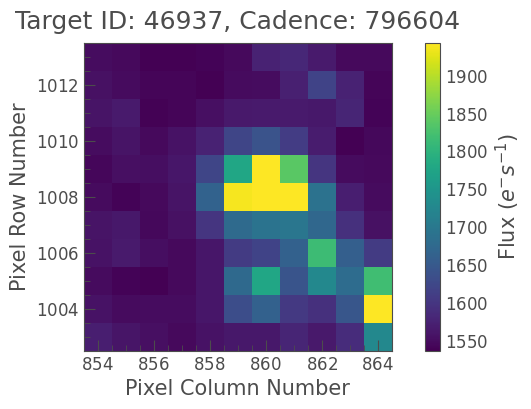

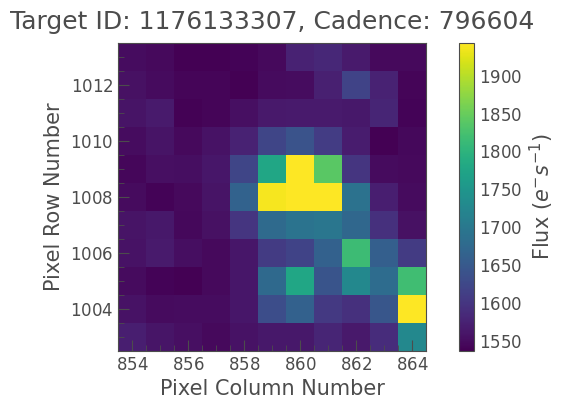

In [13]:
obj= tpfs[0]
obj2=tpfs[1]
obj.plot()
plt.show()
obj2.plot()
plt.show()

In [17]:
machine = psf.TPFMachine.from_TPFs(tpfs, dr=3)
machine

2023-12-22 10:38:00,582 - astroquery - INFO - Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


2023-12-22 10:40:22,099 - psfmachine.tpf - WARNING - Some sources do not have values in 'gaia.phot_rp_mean_flux''. Will default to 'gaia.phot_g_mean_flux' for missing values.
Creating delta arrays: 100%|█████████████████████████████████████████████████████| 1725/1725 [00:02<00:00, 722.12it/s]
2023-12-22 10:40:24,912 - psfmachine.tpf - WARNING - Region is too crowded (nsources/npixels > 0.2), setting limiting magnitude to 16 for contaminant sources.


TPFMachine (N sources, N times, N pixels): (1725, 18401, 5809)

In [18]:
machine.sources

,designation,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_flux,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_bp_mean_flux,phot_rp_mean_flux,clean_flag,tpf_id
0,Gaia DR3 5047360908161005184,48.597154,-35.033896,2.849495,0.085517,8.355612,-9.728789,1598.272261,17.678240,19.079914,16.507080,318.750845,1978.456476,0,None
1,Gaia DR3 5047534527918471936,46.234338,-36.080691,1.513065,0.066386,-10.159084,13.447475,2873.357984,17.041393,17.916363,16.113224,930.832232,2843.600155,0,None
2,Gaia DR3 5047561740831364736,47.453582,-36.047577,3.760207,0.068196,27.857182,3.939360,2152.457764,17.355030,18.921116,16.153515,368.952671,2740.012785,0,None
3,Gaia DR3 5047561809550842752,47.434635,-36.045374,0.885199,0.013427,24.323069,-2.637068,55432.678408,13.827952,14.178903,13.314727,29097.504627,37434.102352,0,None
4,Gaia DR3 5044113736789810816,44.983751,-41.007071,2.095817,0.075513,5.182217,0.723795,1862.844970,17.511925,18.708549,16.444273,448.742509,2096.280056,0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,Gaia DR3 4850228094026705152,52.757530,-39.752885,1.637730,0.216006,5.039752,-1.941803,2395.020054,17.239094,18.321070,16.076586,641.193269,2941.196757,0,None
1721,Gaia DR3 4851128868927776640,50.367442,-41.888816,0.858000,0.063951,15.428960,4.075157,2230.332449,17.316442,17.949036,16.560410,903.239668,1883.624354,0,None
1722,Gaia DR3 4851128868927776768,50.365308,-41.891063,0.724316,0.083025,-4.545504,-9.942524,1499.571641,17.747448,18.324854,17.050140,638.962667,1199.781253,0,None
1723,Gaia DR3 4851128972006990592,50.370748,-41.865378,0.745279,0.019474,-6.537162,-4.718107,21715.787813,14.845428,15.157031,14.371723,11819.649323,14140.639101,0,None


In [ ]:
machine.build_time_model()

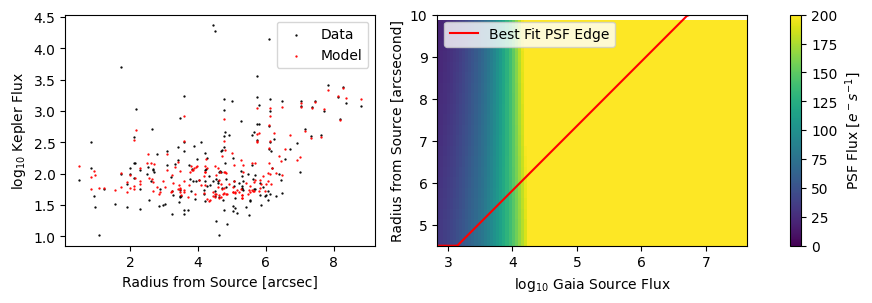

In [35]:
machine._get_source_mask(
    upper_radius_limit=10.0,
    lower_radius_limit=4.5,
    upper_flux_limit=5e5,
    lower_flux_limit=100,
    correct_centroid_offset=False,
    plot=True,
)

In [36]:
machine.source_mask, machine.uncontaminated_source_mask

(<1725x5809 sparse matrix of type '<class 'numpy.bool_'>'
 	with 287 stored elements in Compressed Sparse Row format>,
 <1725x5809 sparse matrix of type '<class 'numpy.bool_'>'
 	with 0 stored elements in Compressed Sparse Row format>)

In [32]:
machine.build_shape_model(
    upper_radius_limit=28.0,
    lower_radius_limit=4.5,
    upper_flux_limit=2e5,
    lower_flux_limit=100,
    correct_centroid_offset=False,
    plot=True,
);

ValueError: zero-size array to reduction operation maximum which has no identity

Fitting 68 Sources (w. VA): 100%|████████████████████████████████████████████████| 18401/18401 [00:42<00:00, 433.55it/s]


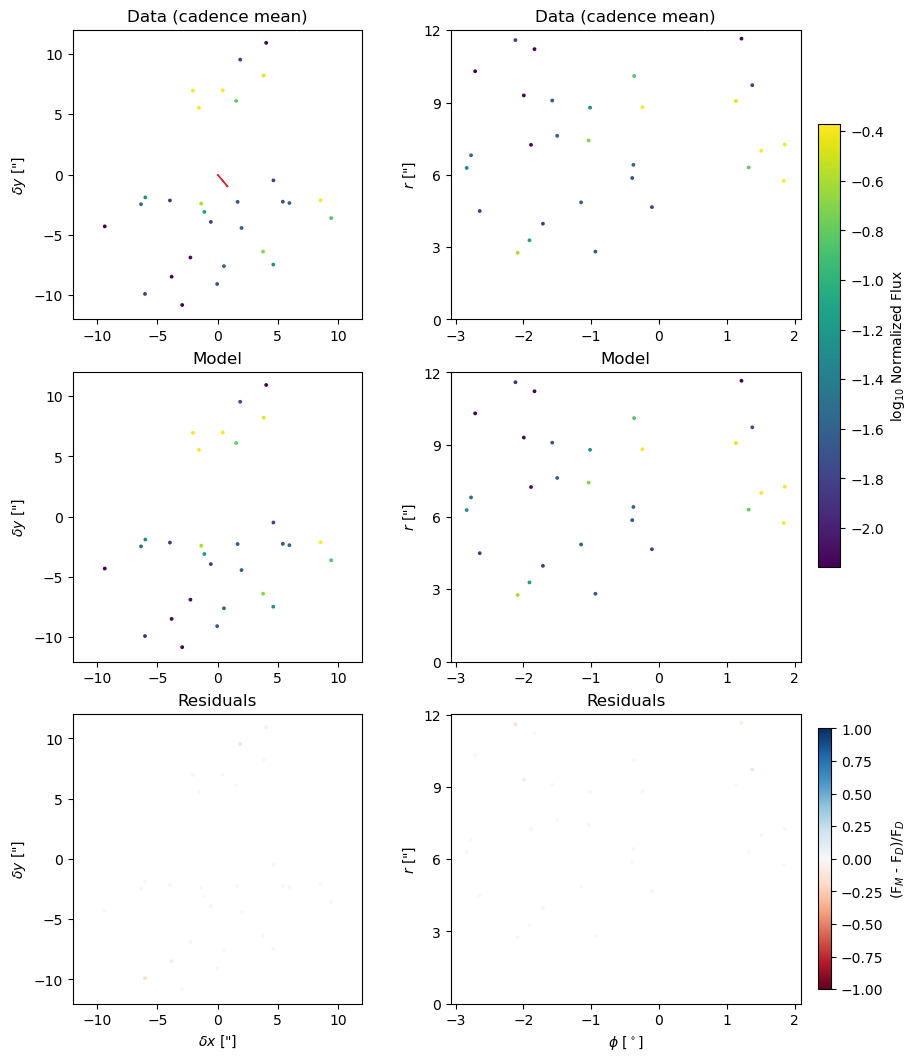

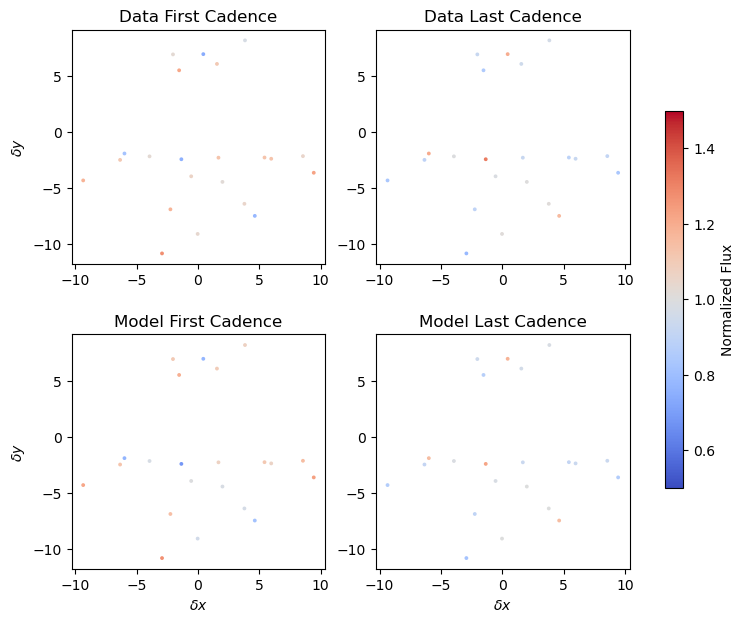

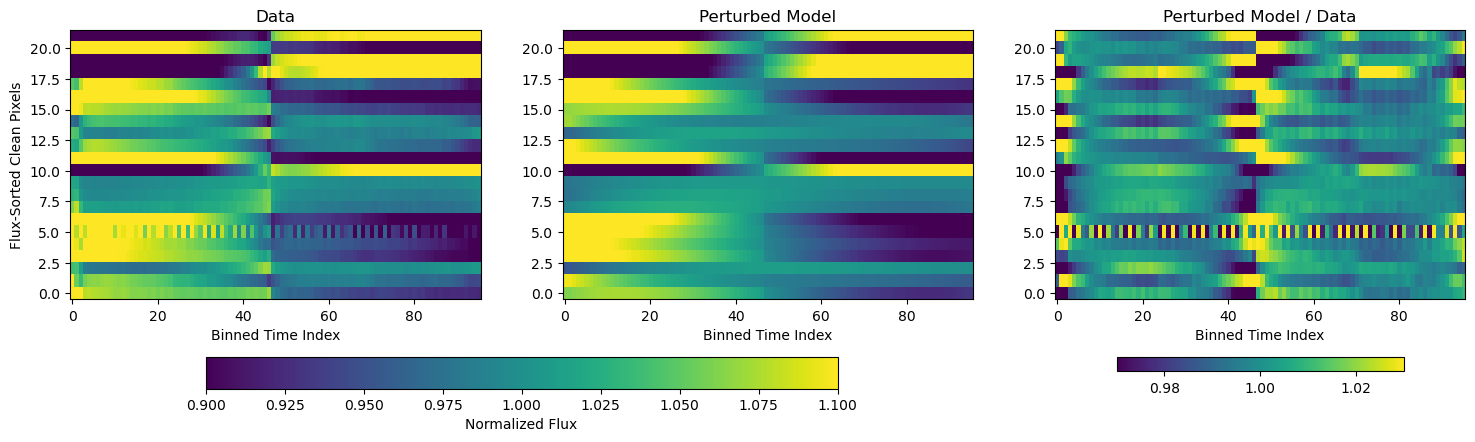

In [44]:
machine.fit_lightcurves(plot=True, fit_va=True)
plt.show()

In [45]:
machine.lcs
#OJO, salen como objetos de KeplerLightCurve y no de TessLightCurve ¿?


LightCurveCollection of 68 objects:
    0: <KeplerLightCurve LABEL="Gaia DR2 4846692202071083264">
    1: <KeplerLightCurve LABEL="Gaia DR2 4847714743588310400">
    2: <KeplerLightCurve LABEL="Gaia DR2 4850228094026705152">
    3: <KeplerLightCurve LABEL="Gaia DR2 4851523421803460224">
    4: <KeplerLightCurve LABEL="Gaia DR2 4852275380381728512">
    5: <KeplerLightCurve LABEL="Gaia DR2 6222383932220201728">
    6: <KeplerLightCurve LABEL="Gaia DR2 6222360498878441472">
    7: <KeplerLightCurve LABEL="Gaia DR2 6222363419456203904">
    8: <KeplerLightCurve LABEL="Gaia DR2 6222363389392312448">
    9: <KeplerLightCurve LABEL="Gaia DR2 6222383936514196736">
    10: <KeplerLightCurve LABEL="Gaia DR2 6222360464518695552">
    11: <KeplerLightCurve LABEL="Gaia DR2 6222363355032569984">
    12: <KeplerLightCurve LABEL="Gaia DR2 6222366447409028096">
    13: <KeplerLightCurve LABEL="Gaia DR2 6222383799077005184">
    14: <KeplerLightCurve LABEL="Gaia DR2 6222360120921286912">
    15: <Keple

In [46]:
machine.sources[machine.sources.tpf_id == 46937]
#machine.sources[machine.sources.tpf_id == 1176133307]   
#Buscar en código porqué salen puros None en columna tpf_id

,designation,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_flux,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,phot_bp_mean_flux,phot_rp_mean_flux,clean_flag,tpf_id


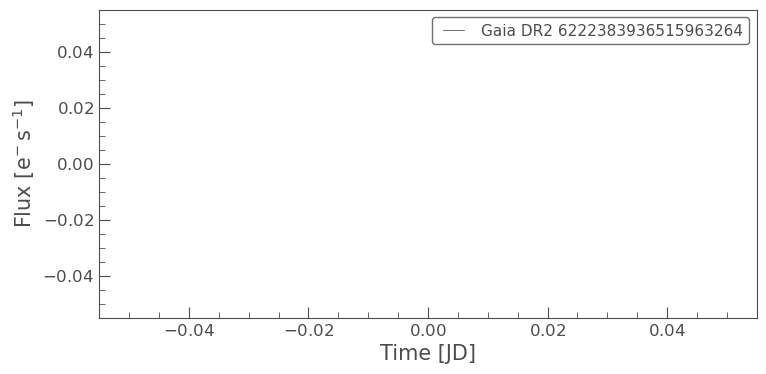

In [47]:
#TIC 46937 = Gaia DR2 6222383936515963264


machine.lcs[21].plot()
plt.show()
# no parece que corrija el Velocity Aberration: activar el parámetro. 
#OJO: busqué y  fit_va = True por default. Entonces qué¿? :(
# Plot a veces sale vacío. OJO: preguntar por qué!!!!!!

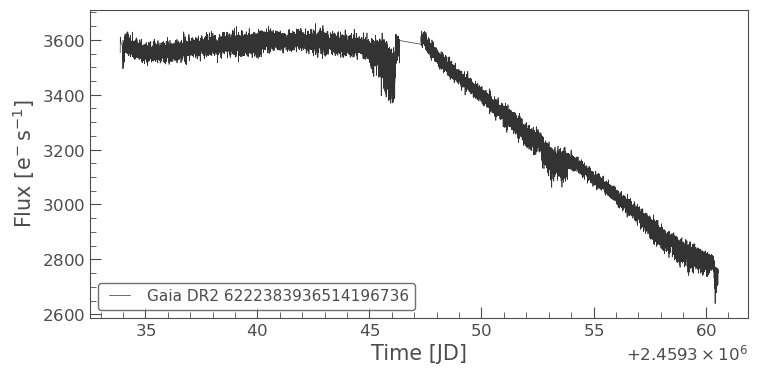

In [48]:
#TIC 1176133307 = Gaia DR2 6222383936514196736


machine.lcs[9].plot()
plt.show()


# Plot vacío. OJO: preguntar por qué!!!!!!

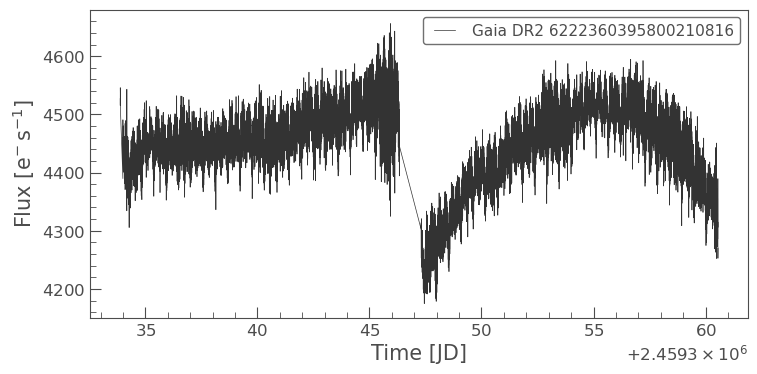

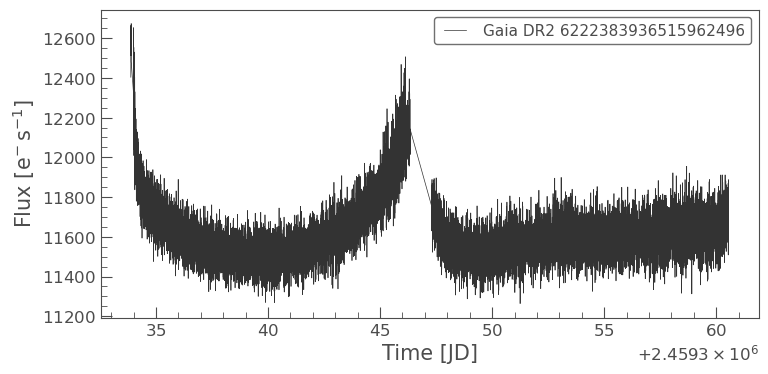

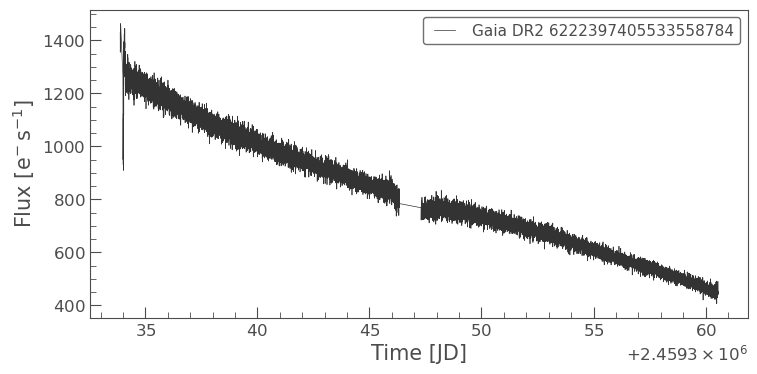

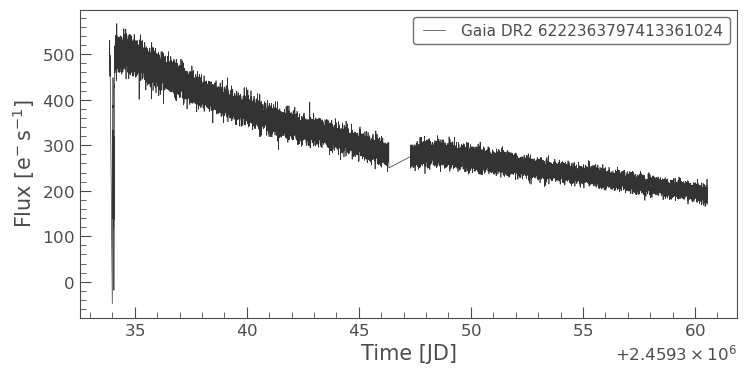

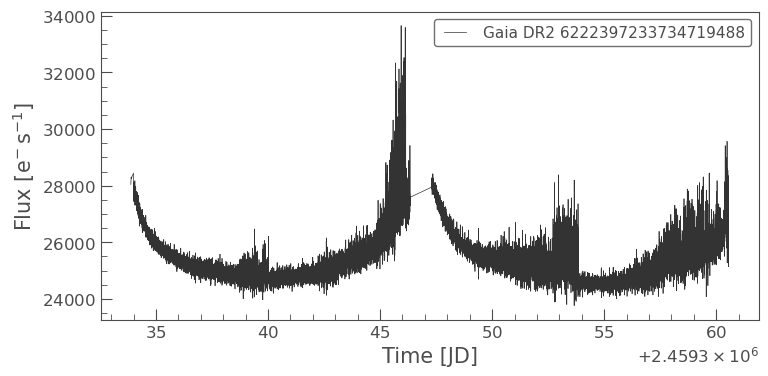

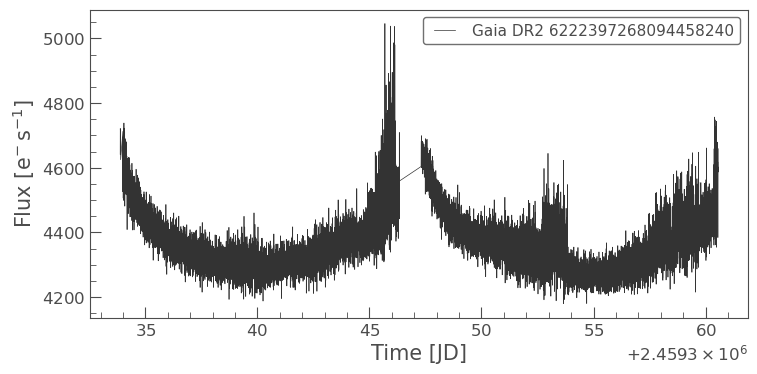

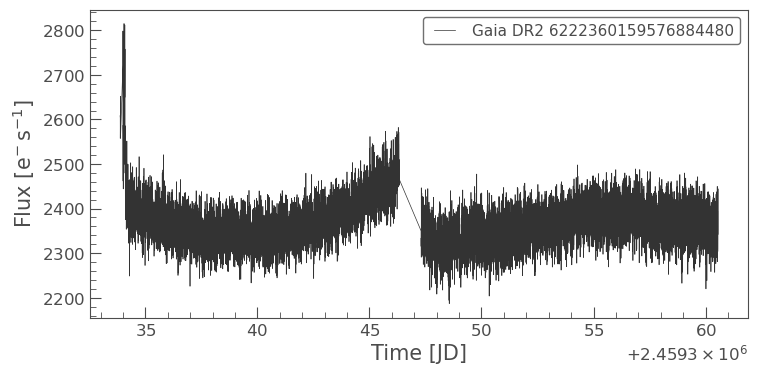

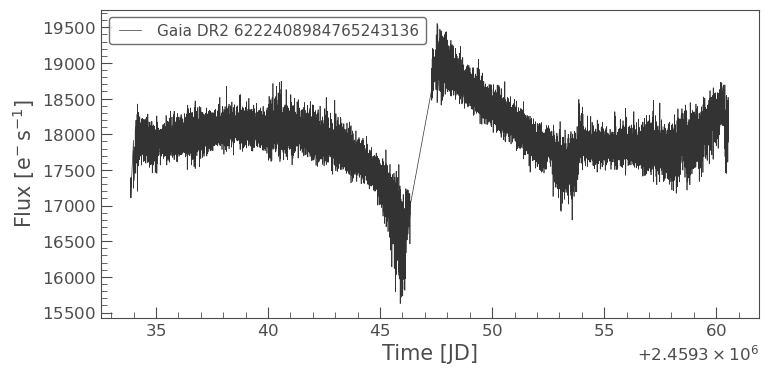

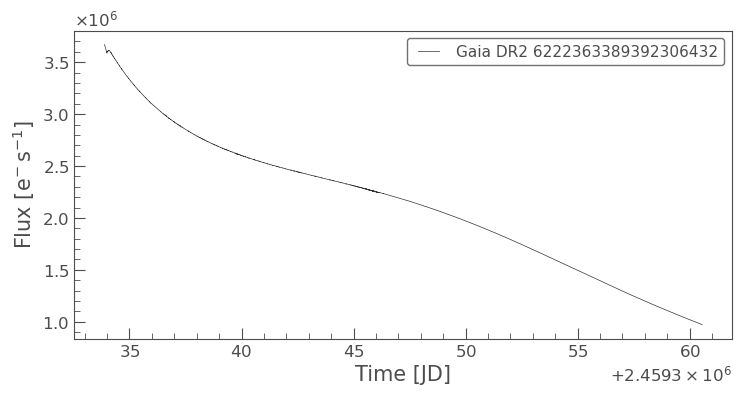

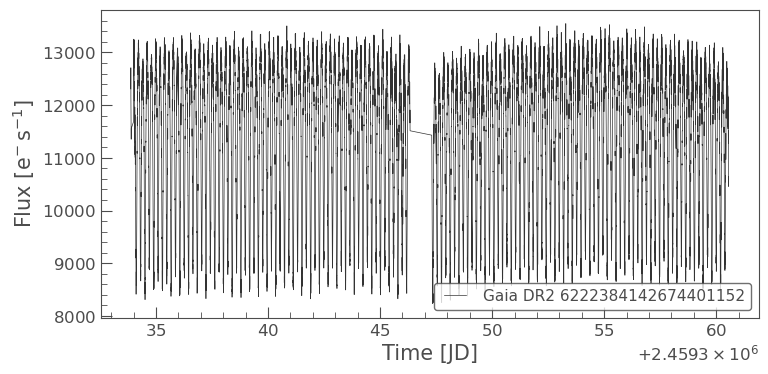

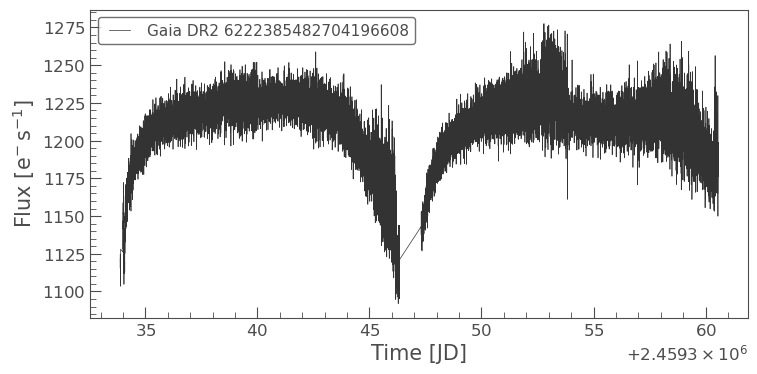

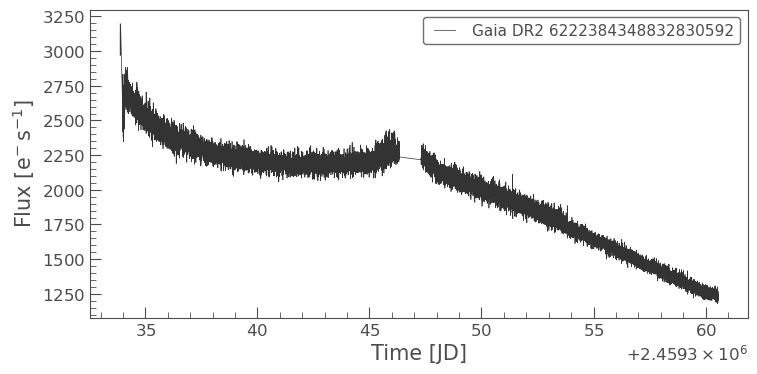

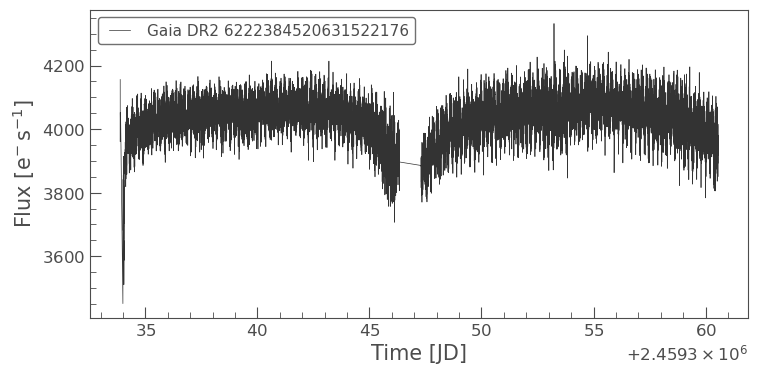

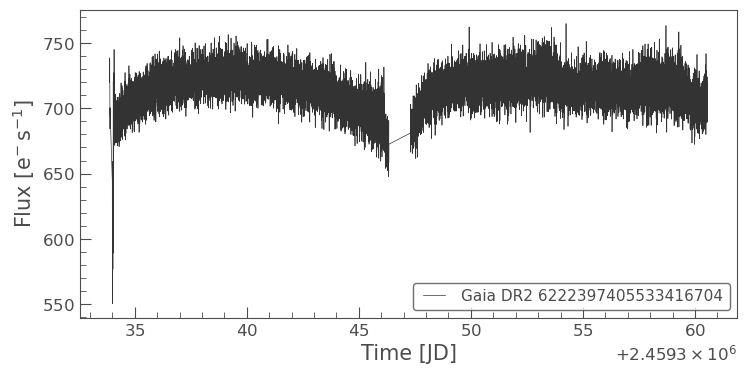

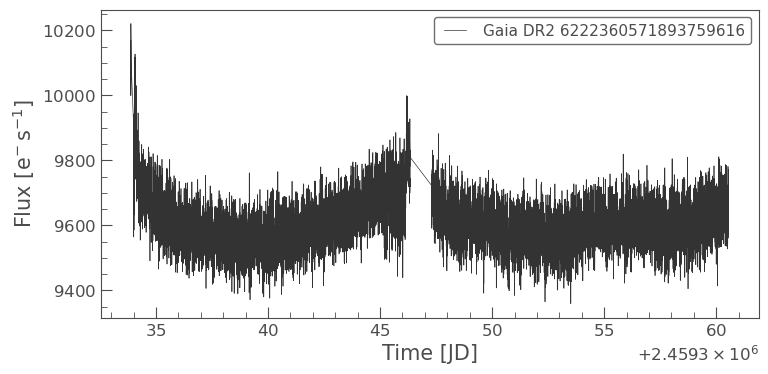

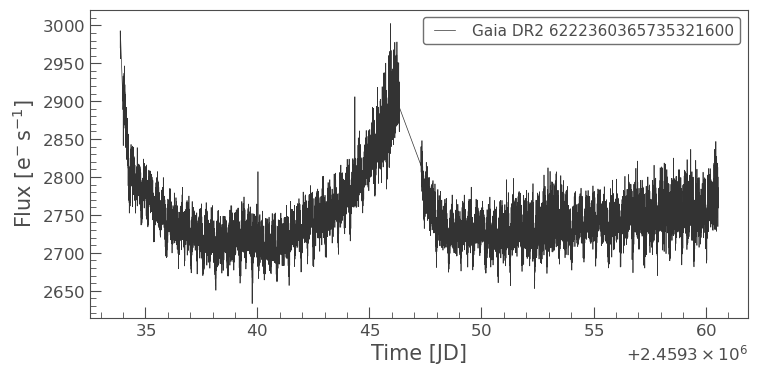

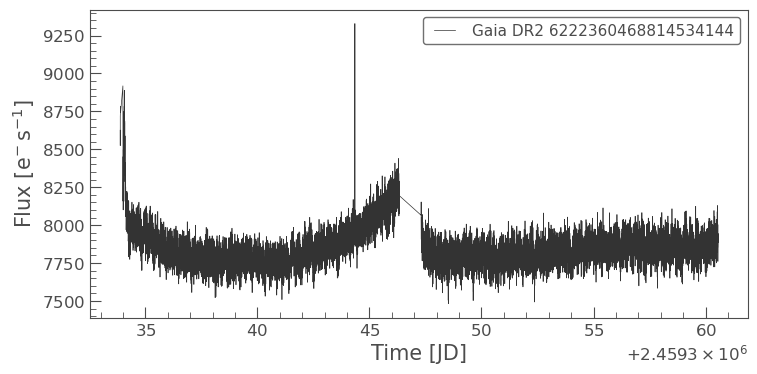

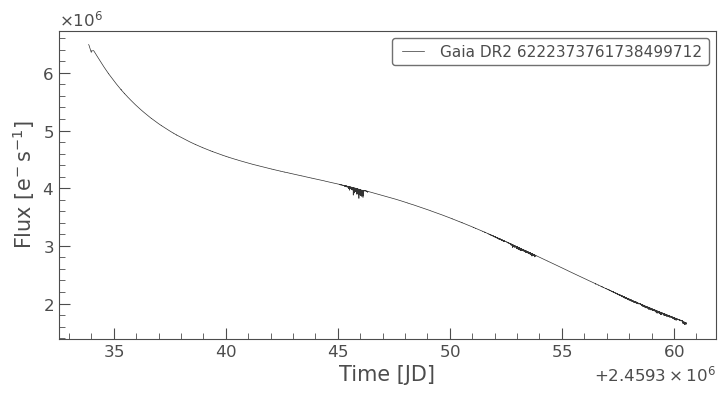

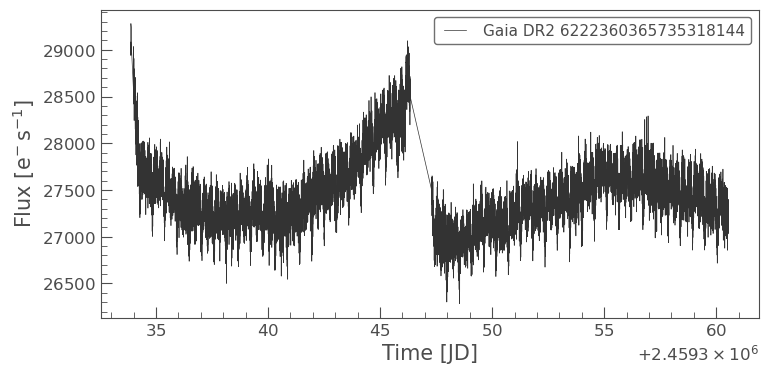

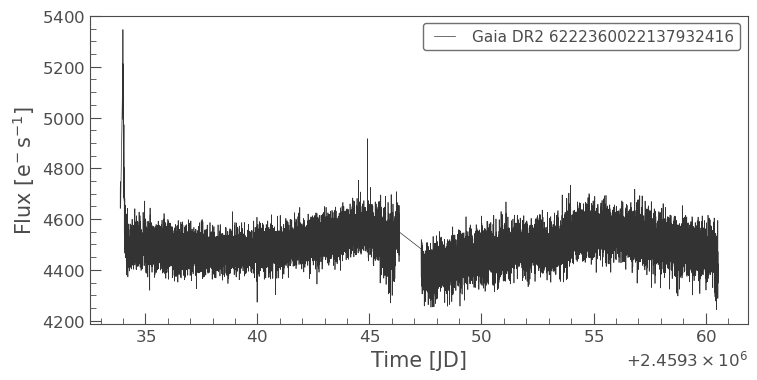

In [35]:
for lc in machine.lcs[::]:
    if np.isnan(lc.flux).all():
        continue
    ax = lc.plot()
    plt.show()